In [1]:
import matplotlib.pyplot as plt

In [2]:
import numpy as np
from scipy.integrate import solve_ivp

def f_and_jac(Y, kappa, lam, mu, mub):
    """
    Returns f(Y) and the Jacobian D_Y f(Y) for the symmetric reduced system.
    Y = [u, a, b, c, d, v]
    """
    u, a, b, c, d, v = Y
    M = a + c + d

    # f(Y)
    fu = -2.0 * kappa * lam * u * M
    fa = -mu * a + kappa * lam * (u - a) * M
    fb =  mu * a - kappa * lam * b * M
    fc =  2.0 * kappa * lam * a * M - mub * c
    fd =  kappa * lam * b * M - mu * d
    fv =  mub * c + 2.0 * mu * d
    f = np.array([fu, fa, fb, fc, fd, fv], dtype=float)

    # Jacobian J = D_Y f
    J = np.zeros((6, 6), dtype=float)

    # f_u = -2 k lam u M
    J[0,0] = -2.0 * kappa * lam * M                 # d/du
    J[0,1] = -2.0 * kappa * lam * u                 # d/da via M
    J[0,3] = -2.0 * kappa * lam * u                 # d/dc via M
    J[0,4] = -2.0 * kappa * lam * u                 # d/dd via M

    # f_a = -mu a + k lam (u-a) M
    J[1,0] =  kappa * lam * M                        # d/du
    J[1,1] = -mu + kappa * lam * (-(M) + (u - a))     # d/da : (u-a)*dM/da + d(u-a)/da * M
    J[1,3] =  kappa * lam * (u - a)                   # d/dc via dM/dc
    J[1,4] =  kappa * lam * (u - a)                   # d/dd via dM/dd

    # f_b = mu a - k lam b M
    J[2,1] =  mu - kappa * lam * b                   # d/da : mu - k lam b*dM/da
    J[2,2] = -kappa * lam * M                        # d/db
    J[2,3] = -kappa * lam * b                        # d/dc via M
    J[2,4] = -kappa * lam * b                        # d/dd via M

    # f_c = 2 k lam a M - mub c
    J[3,1] =  2.0 * kappa * lam * (M + a)            # d/da : 2k lam (M + a*dM/da)
    J[3,3] =  2.0 * kappa * lam * a - mub            # d/dc : 2k lam a*dM/dc - mub
    J[3,4] =  2.0 * kappa * lam * a                  # d/dd : 2k lam a*dM/dd

    # f_d = k lam b M - mu d
    J[4,1] =  kappa * lam * b                        # d/da via M
    J[4,2] =  kappa * lam * M                        # d/db
    J[4,3] =  kappa * lam * b                        # d/dc via M
    J[4,4] =  kappa * lam * b - mu                   # d/dd

    # f_v = mub c + 2 mu d
    J[5,3] =  mub
    J[5,4] =  2.0 * mu

    return f, J


def augmented_rhs(t, Z, kappa, lam, mu, mub):
    """
    Z = [Y; S] where Y in R^6, S in R^6 is dY/d(mub)
    """
    Y = Z[:6]
    S = Z[6:]

    f, J = f_and_jac(Y, kappa, lam, mu, mub)

    # partial_{mub} f = (0,0,0,-c,0,c)
    c = Y[3]
    df_dmub = np.array([0.0, 0.0, 0.0, -c, 0.0, c], dtype=float)

    Sdot = J @ S + df_dmub
    return np.concatenate([f, Sdot])


def run_sensitivity(kappa=10.0, lam=0.3, mu=1.0, mub=0.5, I0=1e-6,
                    tmax=200.0, ngrid=20000):
    # symmetric initial condition: a(0)=I0, all others 0, u adjusts, v=0
    u0 = 1.0 - 2.0*I0
    Y0 = np.array([u0, I0, 0.0, 0.0, 0.0, 0.0], dtype=float)
    S0 = np.zeros(6, dtype=float)
    Z0 = np.concatenate([Y0, S0])

    t_eval = np.linspace(0.0, tmax, ngrid)
    sol = solve_ivp(
        augmented_rhs, (0.0, tmax), Z0,
        t_eval=t_eval,
        args=(kappa, lam, mu, mub),
        rtol=1e-8, atol=1e-12,
        method="RK45"  # try "BDF" if you hit stiffness
    )

    t = sol.t
    Y = sol.y[:6, :]
    S = sol.y[6:, :]

    u, a, b, c, d, v = Y
    su, sa, sb, sc, sd, sv = S

    # J(t) = 2a + c + 2d and sensitivity dJ/dmub = 2 sa + sc + 2 sd
    J = 2.0*a + c + 2.0*d
    dJ = 2.0*sa + sc + 2.0*sd

    # Peak sensitivity: if peak is interior, d/dmub Jmax = dJ(t*) at peak time t*
    idx_peak = int(np.argmax(J))
    t_star = t[idx_peak]
    Jmax = J[idx_peak]
    dJmax_dmub = dJ[idx_peak]

    return t, Y, S, J, dJ, (t_star, Jmax, dJmax_dmub)


t, Y, S, J, dJ, (t_star, Jmax, dJmax_dmub) = run_sensitivity(
        kappa=10.0, lam=0.6, mu=1.0, mub=0.2, I0=1e-6, tmax=200.0
    )

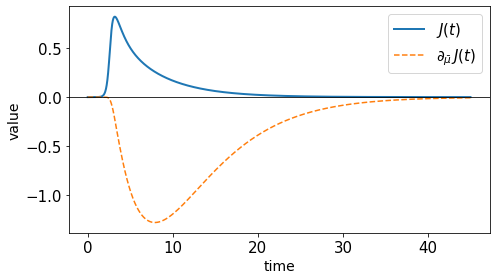

In [3]:
#Time series of J(t) and sensitivity \partialD_\mub J(t)
upto = 4500
plt.figure(figsize=(7,4))
plt.plot(t[:upto], J[:upto], label=r"$J(t)$", linewidth=2)
plt.plot(t[:upto], dJ[:upto], label=r"$\partial_{\bar\mu} \, J(t)$", linestyle="--")
plt.axhline(0.0, color="k", linewidth=0.8)
plt.xlabel("time")
plt.ylabel("value")

plt.xlabel("time", fontsize=14)
plt.ylabel("value", fontsize=14)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.legend(fontsize=15)

plt.tight_layout()
plt.show()